In [1]:
#imports
from pathlib import Path
from collections import Counter

from lxml import etree
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#codes
XML_FILE = Path("../data/dblp.xml")
DTD_FILE = Path("../data/dblp.dtd")

print("XML exists:", XML_FILE.exists())
print("DTD exists:", DTD_FILE.exists())

XML exists: True
DTD exists: True


In [3]:
#Test DTD
with open(DTD_FILE, "rb") as f:
    dtd = etree.DTD(f)

print("DTD loaded successfully")

DTD loaded successfully


In [4]:
#Test XML

parser = etree.XMLParser(
    load_dtd=True,
    resolve_entities=True
)

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag="article"
)

for event, elem in context:
    print("First article:")
    print("Key:", elem.get("key"))
    print("Title:", elem.findtext("title"))
    
    for author in elem.findall("author"):
        print("Author:", author.text)

    break

First article:
Key: persons/CoddD74
Title: Interactive Support for Non-Programmers: The Relational and Network Approaches.
Author: E. F. Codd
Author: C. J. Date 0001


In [5]:
publication_types = Counter()

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    load_dtd=True,
    resolve_entities=True
)

for event, elem in context:

    publication_types[elem.tag] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

print(publication_types)
print("Total records:", sum(publication_types.values()))

Counter({'article': 4458737, 'www': 4202644, 'inproceedings': 3967188, 'phdthesis': 157236, 'incollection': 71185, 'proceedings': 65477, 'book': 21639, 'mastersthesis': 27})
Total records: 12944133


In [6]:
#duplicates

duplicate_keys = Counter()
total_records = 0

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    load_dtd=True,
    resolve_entities=True
)

seen_keys = set()

for event, elem in context:

    total_records += 1

    key = elem.get("key")

    if key:
        if key in seen_keys:
            duplicate_keys[key] += 1
        else:
            seen_keys.add(key)

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

print("Total records:", total_records)
print("Unique keys:", len(seen_keys))
print("Duplicate keys:", sum(duplicate_keys.values()))

if duplicate_keys:
    print("\nExamples:")
    for key, count in duplicate_keys.most_common(10):
        print(key, "→", count + 1, "records")

Total records: 12944133
Unique keys: 12944133
Duplicate keys: 0


In [7]:
#missing values by publication type
missing_by_type = {}

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    load_dtd=True,
    resolve_entities=True
)

for event, elem in context:

    pub_type = elem.tag

    if pub_type not in missing_by_type:
        missing_by_type[pub_type] = {
            "total": 0,
            "missing_author": 0,
            "missing_title": 0,
            "missing_year": 0
        }

    missing_by_type[pub_type]["total"] += 1

    authors = elem.findall("author")
    title = elem.findtext("title")
    year = elem.findtext("year")

    if not authors:
        missing_by_type[pub_type]["missing_author"] += 1

    if not title or not title.strip():
        missing_by_type[pub_type]["missing_title"] += 1

    if not year or not year.strip():
        missing_by_type[pub_type]["missing_year"] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

missing_df = pd.DataFrame.from_dict(
    missing_by_type,
    orient="index"
)

missing_df

,total,missing_author,missing_title,missing_year
mastersthesis,27,0,0,0
book,21639,2553,1,0
incollection,71185,10847,56,0
inproceedings,3967188,5933,1152,0
proceedings,65477,65463,0,0
phdthesis,157236,2,0,0
www,4202644,2764,2679,4202627
article,4458737,31621,4809,3


In [8]:
#missing percentages
missing_percentage_df = missing_df.copy()

for column in ["missing_author", "missing_title", "missing_year"]:
    missing_percentage_df[column] = (
        missing_percentage_df[column]
        / missing_percentage_df["total"]
        * 100
    ).round(2)

missing_percentage_df

,total,missing_author,missing_title,missing_year
mastersthesis,27,0.00,0.00,0.0
book,21639,11.80,0.00,0.0
incollection,71185,15.24,0.08,0.0
inproceedings,3967188,0.15,0.03,0.0
proceedings,65477,99.98,0.00,0.0
phdthesis,157236,0.00,0.00,0.0
www,4202644,0.07,0.06,100.0
article,4458737,0.71,0.11,0.0


In [9]:
#Publication count by year
year_counts = Counter()

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis"
    },
    load_dtd=True,
    resolve_entities=True
)

for event, elem in context:

    year = elem.findtext("year")

    if year:
        year_counts[year] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

year_counts = dict(sorted(year_counts.items()))

print("Number of years:", len(year_counts))
print("Earliest year:", min(year_counts))
print("Latest year:", max(year_counts))

Number of years: 92
Earliest year: 1936
Latest year: 2027


In [10]:
#inspect the latest years
for year, count in list(year_counts.items())[-15:]:
    print(year, "→", count)

2013 → 282920
2014 → 294764
2015 → 305072
2016 → 317414
2017 → 342328
2018 → 378379
2019 → 421258
2020 → 438186
2021 → 466981
2022 → 485656
2023 → 527321
2024 → 585908
2025 → 597424
2026 → 375115
2027 → 1841


In [11]:
future_samples = []

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis"
    },
    load_dtd=True,
    resolve_entities=True
)

for event, elem in context:

    if elem.findtext("year") == "2027":
        future_samples.append({
            "type": elem.tag,
            "key": elem.get("key"),
            "title": elem.findtext("title"),
            "year": elem.findtext("year"),
            "author_count": len(elem.findall("author"))
        })

        if len(future_samples) >= 10:
            break

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

for record in future_samples:
    print("=" * 70)
    print("Type:", record["type"])
    print("Key:", record["key"])
    print("Title:", record["title"])
    print("Year:", record["year"])
    print("Authors:", record["author_count"])

Type: book
Key: series/sfsc/YusoffMN27
Title: Fuzzy Logic, Smart Control, and the Future of Essential Oils - The Science of Aroma
Year: 2027
Authors: 3
Type: book
Key: series/acvpr/Wang27
Title: Multimodal Collaborative Perception for Unmanned Systems
Year: 2027
Authors: 1
Type: book
Key: series/lnbip/Rojas27
Title: Automate It All! - Revamping the Outsourcing Industry
Year: 2027
Authors: 1
Type: book
Key: books/sp/WangJ27
Title: Mechanism-Driven Explainable Urban Spatio-Temporal Prediction
Year: 2027
Authors: 2
Type: book
Key: books/sp/Aykent26
Title: Application of LLM in Vehicle Dynamics and Control Modeling, encompassing Human-Vehicle Interaction - A Thorough Reference for Researchers, Engineers, and Students, 3
Year: 2027
Authors: 1
Type: book
Key: books/sp/VatsalanAK27
Title: Privacy-Preserving Record Linkage - Theory, Applications, and Challenges
Year: 2027
Authors: 3
Type: book
Key: books/ws/AmadioB27
Title: Operational Methods in Semantics
Year: 2027
Authors: 2
Type: proceedin

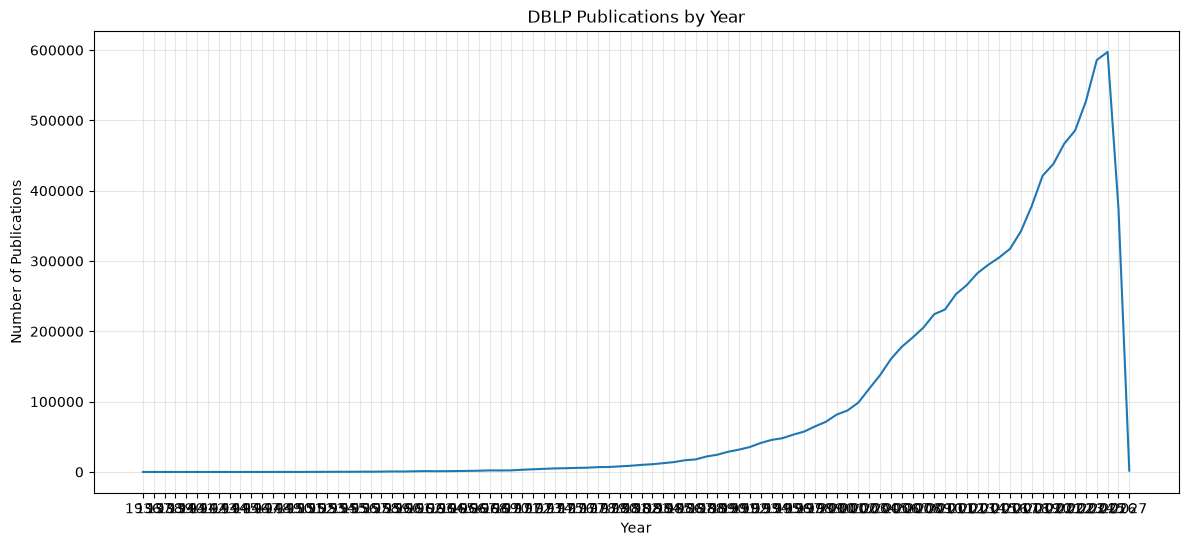

In [12]:
#Visualize publication trend

years = list(year_counts.keys())
counts = list(year_counts.values())

plt.figure(figsize=(14, 6))

plt.plot(years, counts)

plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.title("DBLP Publications by Year")

plt.grid(True, alpha=0.3)

plt.show()

In [13]:
#authors per publication

author_count_distribution = Counter()

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    load_dtd=True,
    resolve_entities=True
)

for event, elem in context:

    author_count = len(elem.findall("author"))

    author_count_distribution[author_count] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

print("Author count distribution:")
for count, publications in sorted(author_count_distribution.items()):
    print(count, "authors →", publications, "publications")

Author count distribution:
0 authors → 119183 publications
1 authors → 5271103 publications
2 authors → 2040186 publications
3 authors → 2010167 publications
4 authors → 1459785 publications
5 authors → 895578 publications
6 authors → 527093 publications
7 authors → 262573 publications
8 authors → 143356 publications
9 authors → 78109 publications
10 authors → 45929 publications
11 authors → 26712 publications
12 authors → 17606 publications
13 authors → 11095 publications
14 authors → 7767 publications
15 authors → 5539 publications
16 authors → 4093 publications
17 authors → 2883 publications
18 authors → 2332 publications
19 authors → 1927 publications
20 authors → 1496 publications
21 authors → 1181 publications
22 authors → 980 publications
23 authors → 823 publications
24 authors → 725 publications
25 authors → 646 publications
26 authors → 516 publications
27 authors → 455 publications
28 authors → 395 publications
29 authors → 344 publications
30 authors → 330 publications
31 a

In [14]:
#summary stats
total_publications = sum(author_count_distribution.values())

total_authors = sum(
    author_count * publications
    for author_count, publications in author_count_distribution.items()
)

average_authors = total_authors / total_publications

# Expand only conceptually for median
cumulative = 0
median_authors = None
middle = total_publications / 2

for author_count, publications in sorted(author_count_distribution.items()):
    cumulative += publications

    if cumulative >= middle:
        median_authors = author_count
        break

single_author = author_count_distribution.get(1, 0)
multi_author = total_publications - author_count_distribution.get(0, 0) - single_author
zero_author = author_count_distribution.get(0, 0)

print("Total publications:", total_publications)
print("Average authors per publication:", round(average_authors, 2))
print("Median authors per publication:", median_authors)
print("Maximum authors on one publication:", max(author_count_distribution))

print()
print("0 authors:", zero_author)
print("1 author:", single_author)
print("2+ authors:", multi_author)

print()
print("Single-author percentage:",
      round(single_author / total_publications * 100, 2), "%")

print("Multi-author percentage:",
      round(multi_author / total_publications * 100, 2), "%")

Total publications: 12944133
Average authors per publication: 2.66
Median authors per publication: 2
Maximum authors on one publication: 450

0 authors: 119183
1 author: 5271103
2+ authors: 7553847

Single-author percentage: 40.72 %
Multi-author percentage: 58.36 %


In [15]:
#collaboration trends by year

collaboration_by_year = {}

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis"
    },
    load_dtd=True,
    resolve_entities=True
)

for event, elem in context:

    year = elem.findtext("year")

    if year:
        author_count = len(elem.findall("author"))

        if year not in collaboration_by_year:
            collaboration_by_year[year] = {
                "publications": 0,
                "total_authors": 0,
                "single_author": 0,
                "multi_author": 0
            }

        collaboration_by_year[year]["publications"] += 1
        collaboration_by_year[year]["total_authors"] += author_count

        if author_count == 1:
            collaboration_by_year[year]["single_author"] += 1
        elif author_count >= 2:
            collaboration_by_year[year]["multi_author"] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

collaboration_df = pd.DataFrame.from_dict(
    collaboration_by_year,
    orient="index"
)

collaboration_df.index.name = "year"
collaboration_df = collaboration_df.sort_index()

collaboration_df["avg_authors"] = (
    collaboration_df["total_authors"]
    / collaboration_df["publications"]
).round(2)

collaboration_df["multi_author_pct"] = (
    collaboration_df["multi_author"]
    / collaboration_df["publications"]
    * 100
).round(2)

collaboration_df

,publications,total_authors,single_author,multi_author,avg_authors,multi_author_pct
year,,,,,,
1936,12,12,12,0,1.00,0.00
1937,16,16,16,0,1.00,0.00
1938,11,12,10,1,1.09,9.09
1939,18,18,18,0,1.00,0.00
1940,10,12,8,2,1.20,20.00
...,...,...,...,...,...,...
2023,527321,2165034,36446,484500,4.11,91.88
2024,585908,2510409,36709,543206,4.28,92.71
2025,597424,2680727,35391,557173,4.49,93.26


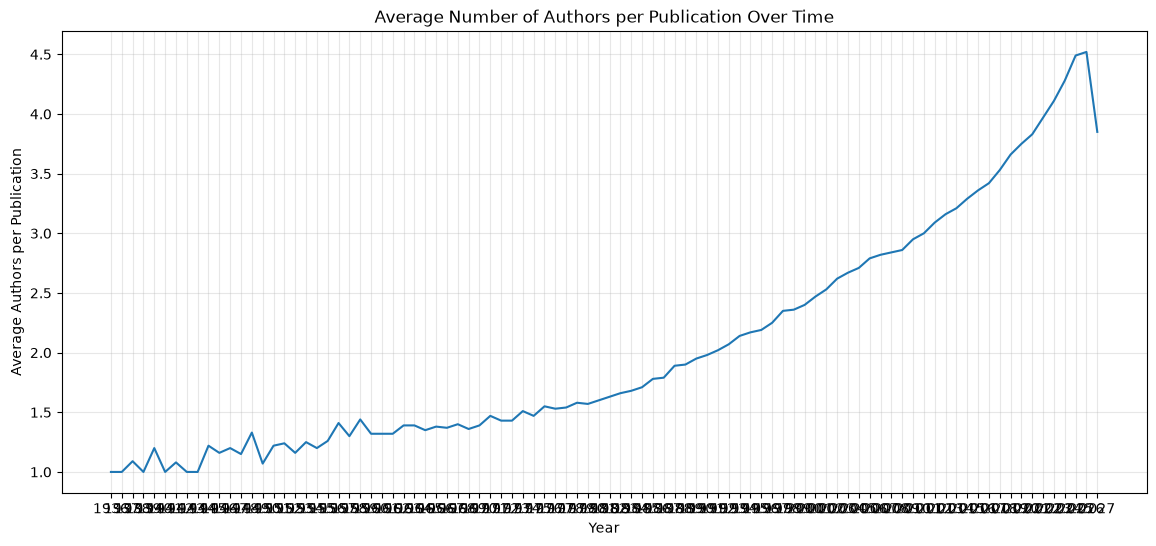

In [16]:
#average authors over time
plt.figure(figsize=(14, 6))

plt.plot(
    collaboration_df.index,
    collaboration_df["avg_authors"]
)

plt.xlabel("Year")
plt.ylabel("Average Authors per Publication")
plt.title("Average Number of Authors per Publication Over Time")

plt.grid(True, alpha=0.3)

plt.show()

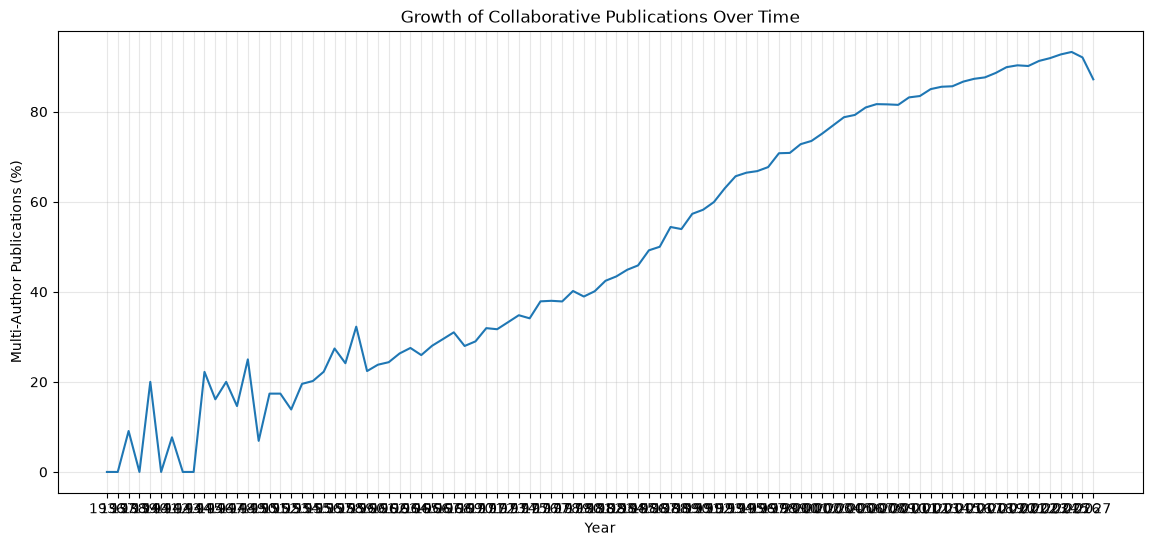

In [17]:
#multi-author percentage
plt.figure(figsize=(14, 6))

plt.plot(
    collaboration_df.index,
    collaboration_df["multi_author_pct"]
)

plt.xlabel("Year")
plt.ylabel("Multi-Author Publications (%)")
plt.title("Growth of Collaborative Publications Over Time")

plt.grid(True, alpha=0.3)

plt.show()

In [18]:
#venues
venue_fields = Counter()

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    load_dtd=True,
    resolve_entities=True
)

for event, elem in context:

    for child in elem:
        if child.tag in {
            "journal",
            "booktitle",
            "publisher",
            "school"
        }:
            venue_fields[child.tag] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

print(venue_fields)

Counter({'journal': 4458737, 'booktitle': 4104906, 'school': 160901, 'publisher': 91467})


In [19]:
#top venues

journal_counts = Counter()
conference_counts = Counter()

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "incollection"
    },
    load_dtd=True,
    resolve_entities=True
)

for event, elem in context:

    journal = elem.findtext("journal")
    booktitle = elem.findtext("booktitle")

    if journal and journal.strip():
        journal_counts[journal.strip()] += 1

    if booktitle and booktitle.strip():
        conference_counts[booktitle.strip()] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

print("Top 20 journals:")
for venue, count in journal_counts.most_common(20):
    print(f"{venue} → {count}")

print("\nTop 20 conferences:")
for venue, count in conference_counts.most_common(20):
    print(f"{venue} → {count}")

Top 20 journals:
CoRR → 979923
IEEE Access → 111565
Sensors → 64311
Remote. Sens. → 36114
Expert Syst. Appl. → 29957
IACR Cryptol. ePrint Arch. → 27324
Neurocomputing → 25125
Appl. Math. Comput. → 22601
IEEE Trans. Geosci. Remote. Sens. → 21923
Multim. Tools Appl. → 21767
IEEE Trans. Instrum. Meas. → 20194
NeuroImage → 20119
IEEE Trans. Veh. Technol. → 19340
IEEE Trans. Ind. Electron. → 19336
IEEE Trans. Commun. → 19022
Bioinform. → 18946
IEEE Trans. Inf. Theory → 18675
Inf. Sci. → 18488
IEEE Internet Things J. → 17794
Discret. Math. → 17378

Top 20 conferences:
ICASSP → 47722
IGARSS → 33702
ICRA → 30221
AAAI → 28468
ICC → 26828
IROS → 26355
CDC → 26040
ACC → 25053
CVPR → 24439
GLOBECOM → 24030
EMBC → 23629
NeurIPS → 23368
ISCAS → 21244
INTERSPEECH → 21172
IJCNN → 19791
SMC → 18687
HICSS → 18682
ICIP → 18512
ICML → 16223
IJCAI → 15192


In [22]:
#Publication types by year

type_by_year = {}

publication_tags = {
    "article",
    "inproceedings",
    "proceedings",
    "book",
    "incollection",
    "phdthesis",
    "mastersthesis"
}

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag=publication_tags,
    load_dtd=True,
    resolve_entities=True
)

for event, elem in context:

    year = elem.findtext("year")

    if year:
        if year not in type_by_year:
            type_by_year[year] = Counter()

        type_by_year[year][elem.tag] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

type_by_year_df = pd.DataFrame.from_dict(
    type_by_year,
    orient="index"
).fillna(0)

type_by_year_df.index.name = "year"
type_by_year_df = type_by_year_df.sort_index()

type_by_year_df

,mastersthesis,incollection,book,proceedings,phdthesis,inproceedings,article
year,,,,,,,
1936,0.0,0.0,0.0,0.0,0.0,0.0,12
1937,0.0,0.0,0.0,0.0,0.0,0.0,16
1938,0.0,0.0,0.0,0.0,1.0,0.0,10
1939,0.0,0.0,0.0,0.0,0.0,0.0,18
1940,0.0,0.0,0.0,0.0,0.0,0.0,10
...,...,...,...,...,...,...,...
2023,0.0,804.0,510.0,3051.0,5965.0,201882.0,315109
2024,0.0,401.0,396.0,2906.0,5337.0,213279.0,363589
2025,0.0,133.0,298.0,2634.0,2754.0,197999.0,393606


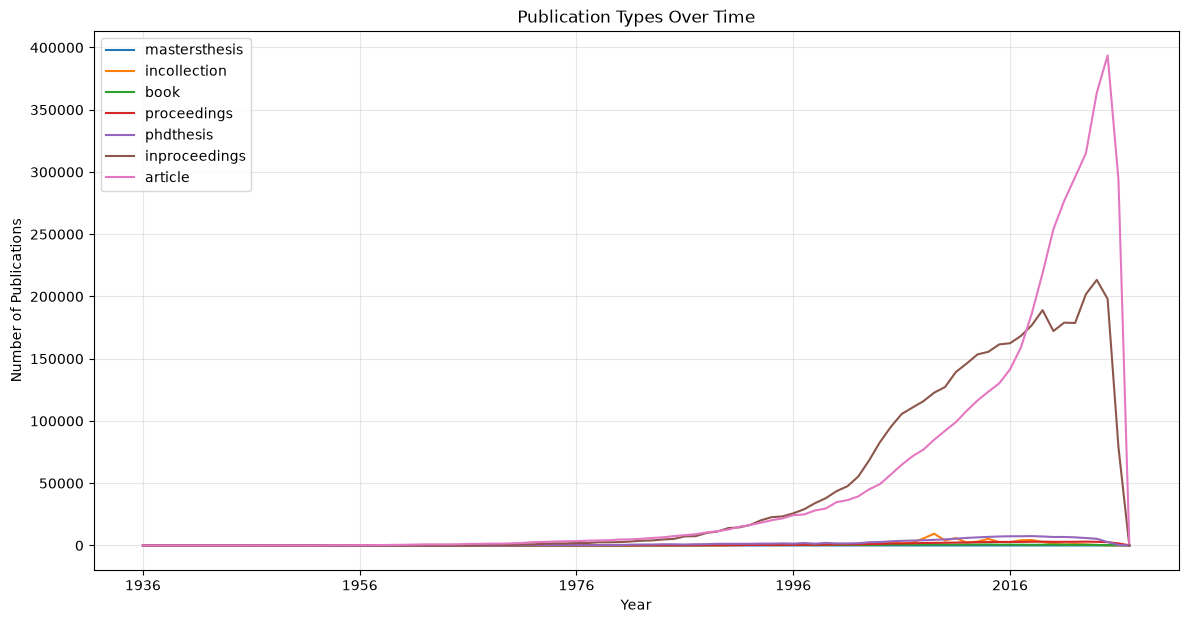

In [21]:
#chart

type_by_year_df.plot(
    figsize=(14, 7)
)

plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.title("Publication Types Over Time")
plt.grid(True, alpha=0.3)
plt.show()